In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [9]:
import pandas as pd

file_path = "data/raw/EV_Data_Explorer2025.xlsx"

excel = pd.ExcelFile(file_path)

excel.sheet_names

['GEVO_EV_2025',
 'Notes',
 'Examples >>',
 'EV sales countries',
 'EV sales macro regions',
 'Other than sales and stock',
 'Regions and countries']

In [4]:
import os

print(os.getcwd())

/Users/abhisheknageshsalian/global-ev-analysis


In [6]:
import sys
print(sys.executable)

/Library/Frameworks/Python.framework/Versions/3.12/bin/python3.12


In [7]:
import sys

!{sys.executable} -m pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]


In [11]:
for sheet in excel.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    print(f"{sheet}: {df.shape}")

GEVO_EV_2025: (16436, 9)
Notes: (4, 3)
Examples >>: (0, 0)
EV sales countries: (63, 16)
EV sales macro regions: (12, 17)
Other than sales and stock: (12, 17)
Regions and countries: (8, 2)


# Driving the Electric Revolution: A Global Analysis of Electric Vehicle Adoption

### Data Visualization – Final Individual Project

**Author:** Abhishek Nagesh Salian

**Dataset:** IEA Global EV Outlook 2025

---

## Project Objective

This project analyses global electric vehicle adoption trends using the IEA Global EV Outlook 2025 dataset. Through exploratory data analysis and interactive Plotly visualizations, the project investigates how EV sales, market share, charging infrastructure, and regional differences have evolved over time.

# 1. Import Libraries

In [12]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 2. Load Dataset

In [13]:
file_path = "data/raw/EV_Data_Explorer2025.xlsx"

ev = pd.read_excel(
    file_path,
    sheet_name="GEVO_EV_2025"
)

ev.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,World,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,170000000.0,_World
1,World,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,150000000.0,_World
2,China,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,91000000.0,Other
3,China,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,82000000.0,Other
4,World,Projection-STEPS,EV stock,Cars,PHEV,2030,Vehicles,82000000.0,_World


In [14]:
ev.shape

(16436, 9)

In [15]:
ev.columns.tolist()

['region_country',
 'category',
 'parameter',
 'mode',
 'powertrain',
 'year',
 'unit',
 'value',
 'Aggregate group']

In [16]:
ev.info()

<class 'pandas.DataFrame'>
RangeIndex: 16436 entries, 0 to 16435
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region_country   16436 non-null  str    
 1   category         16436 non-null  str    
 2   parameter        16436 non-null  str    
 3   mode             16436 non-null  str    
 4   powertrain       16436 non-null  str    
 5   year             16436 non-null  int64  
 6   unit             16436 non-null  str    
 7   value            16436 non-null  float64
 8   Aggregate group  16436 non-null  str    
dtypes: float64(1), int64(1), str(7)
memory usage: 2.0 MB


In [17]:
ev.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,World,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,170000000.0,_World
1,World,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,150000000.0,_World
2,China,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,91000000.0,Other
3,China,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,82000000.0,Other
4,World,Projection-STEPS,EV stock,Cars,PHEV,2030,Vehicles,82000000.0,_World


# 3. Data Cleaning

In [18]:
ev.isnull().sum()

region_country     0
category           0
parameter          0
mode               0
powertrain         0
year               0
unit               0
value              0
Aggregate group    0
dtype: int64

In [19]:
ev.duplicated().sum()

np.int64(12)

In [20]:
for col in ev.select_dtypes(include="object").columns:
    print(f"\n===== {col} =====")
    print(ev[col].unique())


===== region_country =====
<ArrowStringArray>
[                    'World',                     'China',
              'Asia Pacific',                     'India',
                    'Europe',         'Rest of the world',
                       'USA',                      'EU27',
             'North America',                   'Germany',
                  'Viet Nam',            'United Kingdom',
                    'France',                    'Norway',
                    'Canada',               'Netherlands',
 'Central and South America',                     'Korea',
                 'Indonesia',                    'Sweden',
                   'Belgium',                   'Denmark',
                     'Japan',                     'Italy',
                 'Australia',                   'Turkiye',
                     'Spain',               'Switzerland',
                   'Austria',                    'Israel',
                  'Thailand',                   'Finland',
         

/var/folders/41/vny736b909l2ld5tm2h469rr0000gn/T/ipykernel_63174/1685293829.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in ev.select_dtypes(include="object").columns:


In [22]:
ev.describe()

,year,value
count,16436.000000,1.643600e+04
mean,2018.852336,2.678267e+05
std,4.271488,3.325613e+06
min,2010.000000,1.200000e-06
25%,2016.000000,1.000000e+00
50%,2019.000000,4.900000e+01
75%,2022.000000,2.500000e+03
max,2030.000000,1.700000e+08


In [23]:
print("Rows:", ev.shape[0])
print("Columns:", ev.shape[1])

Rows: 16436
Columns: 9


In [24]:
ev["parameter"].value_counts()

parameter
EV stock                         4573
EV sales                         4306
EV sales share                   2502
EV stock share                   2414
EV charging points                899
Oil displacement, million lge     563
Oil displacement Mbd              563
Battery demand                    557
Electricity demand                 59
Name: count, dtype: int64

In [25]:
ev["mode"].value_counts()

mode
Cars                5370
2 and 3 wheelers    2928
Vans                2921
Buses               2695
Trucks              1623
EV                   899
Name: count, dtype: int64

In [26]:
ev["powertrain"].value_counts()

powertrain
EV                         6658
BEV                        4917
PHEV                       2394
FCEV                       1568
Publicly available slow     465
Publicly available fast     434
Name: count, dtype: int64

In [27]:
ev["category"].value_counts()

category
Historical          14616
Projection-STEPS     1820
Name: count, dtype: int64

In [28]:
sorted(ev["year"].unique())

[np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019),
 np.int64(2020),
 np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024),
 np.int64(2030)]

In [29]:
len(ev["region_country"].unique())

63

In [30]:
sorted(ev["region_country"].unique())

['Africa',
 'Asia Pacific',
 'Australia',
 'Austria',
 'Belgium',
 'Brazil',
 'Bulgaria',
 'Canada',
 'Central and South America',
 'Chile',
 'China',
 'Colombia',
 'Costa Rica',
 'Croatia',
 'Cyprus',
 'Czech Republic',
 'Denmark',
 'EU27',
 'Estonia',
 'Europe',
 'Finland',
 'France',
 'Germany',
 'Greece',
 'Hungary',
 'Iceland',
 'India',
 'Indonesia',
 'Ireland',
 'Israel',
 'Italy',
 'Japan',
 'Jordan',
 'Korea',
 'Latvia',
 'Lithuania',
 'Luxembourg',
 'Malaysia',
 'Mexico',
 'Middle East and Caspian',
 'Netherlands',
 'New Zealand',
 'North America',
 'Norway',
 'Poland',
 'Portugal',
 'Rest of the world',
 'Romania',
 'Russia',
 'Seychelles',
 'Slovakia',
 'Slovenia',
 'South Africa',
 'Spain',
 'Sweden',
 'Switzerland',
 'Thailand',
 'Turkiye',
 'USA',
 'United Kingdom',
 'Uzbekistan',
 'Viet Nam',
 'World']

# 4. Create Analysis Dataset

In [31]:
ev_analysis = ev[
    (ev["category"] == "Historical") &
    (ev["mode"] == "Cars") &
    (ev["parameter"].isin(["EV sales", "EV stock"])) &
    (ev["powertrain"].isin(["BEV", "PHEV"]))
].copy()

In [32]:
ev_analysis.shape

(2673, 9)

In [33]:
ev_analysis.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
27,World,Historical,EV stock,Cars,BEV,2024,Vehicles,39000000.0,_World
39,World,Historical,EV stock,Cars,BEV,2023,Vehicles,28000000.0,_World
43,Asia Pacific,Historical,EV stock,Cars,BEV,2024,Vehicles,24000000.0,Aggregate_sales_stock
44,China,Historical,EV stock,Cars,BEV,2024,Vehicles,23000000.0,Other
49,World,Historical,EV stock,Cars,PHEV,2024,Vehicles,19000000.0,_World


In [34]:
print("Categories:", ev_analysis["category"].unique())
print("Modes:", ev_analysis["mode"].unique())
print("Parameters:", ev_analysis["parameter"].unique())
print("Powertrains:", ev_analysis["powertrain"].unique())

Categories: <ArrowStringArray>
['Historical']
Length: 1, dtype: str
Modes: <ArrowStringArray>
['Cars']
Length: 1, dtype: str
Parameters: <ArrowStringArray>
['EV stock', 'EV sales']
Length: 2, dtype: str
Powertrains: <ArrowStringArray>
['BEV', 'PHEV']
Length: 2, dtype: str


In [35]:
ev_analysis = ev_analysis.drop_duplicates()

print("Shape after removing duplicates:", ev_analysis.shape)

Shape after removing duplicates: (2673, 9)


In [36]:
ev_analysis.reset_index(drop=True, inplace=True)

In [37]:
ev_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 2673 entries, 0 to 2672
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region_country   2673 non-null   str    
 1   category         2673 non-null   str    
 2   parameter        2673 non-null   str    
 3   mode             2673 non-null   str    
 4   powertrain       2673 non-null   str    
 5   year             2673 non-null   int64  
 6   unit             2673 non-null   str    
 7   value            2673 non-null   float64
 8   Aggregate group  2673 non-null   str    
dtypes: float64(1), int64(1), str(7)
memory usage: 316.5 KB


In [38]:
ev_analysis.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,World,Historical,EV stock,Cars,BEV,2024,Vehicles,39000000.0,_World
1,World,Historical,EV stock,Cars,BEV,2023,Vehicles,28000000.0,_World
2,Asia Pacific,Historical,EV stock,Cars,BEV,2024,Vehicles,24000000.0,Aggregate_sales_stock
3,China,Historical,EV stock,Cars,BEV,2024,Vehicles,23000000.0,Other
4,World,Historical,EV stock,Cars,PHEV,2024,Vehicles,19000000.0,_World


# 5. Analytical Question 1

## Question

**How have global electric vehicle sales evolved over time, and how do Battery Electric Vehicles (BEVs) compare with Plug-in Hybrid Electric Vehicles (PHEVs)?**

### Why this question?

Understanding the historical growth of EV sales and comparing BEVs with PHEVs helps identify global adoption trends and reveals which technology has driven the transition toward sustainable transportation.

In [39]:
sales_world = (
    ev_analysis[
        (ev_analysis["parameter"] == "EV sales") &
        (ev_analysis["region_country"] == "World")
    ]
    .groupby(["year", "powertrain"], as_index=False)["value"]
    .sum()
)

sales_world.head()

,year,powertrain,value
0,2010,BEV,7000.0
1,2010,PHEV,450.0
2,2011,BEV,40000.0
3,2011,PHEV,9000.0
4,2012,BEV,58000.0


fig = px.line(
    sales_world,
    x="year",
    y="value",
    color="powertrain",
    markers=True,
    title="Global EV Sales Have Increased Rapidly, with BEVs Leading Market Growth",
    color_discrete_map={
        "BEV": "#1f77b4",
        "PHEV": "#ff7f0e"
    }
)

fig.update_traces(line=dict(width=4), marker=dict(size=8))

fig.update_layout(
    template="plotly_white",
    title=dict(
        text="Global EV Sales Have Increased Rapidly, with BEVs Leading Market Growth",
        x=0.5,
        font=dict(size=22)
    ),
    font=dict(size=14),
    width=1000,
    height=600,
    legend=dict(
        orientation="h",
        y=1.08,
        x=0.5,
        xanchor="center",
        title=""
    ),
    xaxis_title="Year",
    yaxis_title="Vehicles Sold",
    hovermode="x unified"
)

fig.update_xaxes(showgrid=False)

fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgrey",
    tickformat=",.0s"
)

# Annotate latest values
latest = sales_world[sales_world["year"] == sales_world["year"].max()]

for _, row in latest.iterrows():
    fig.add_annotation(
        x=row["year"],
        y=row["value"],
        text=f'{row["powertrain"]}: {row["value"]/1e6:.1f}M',
        showarrow=True,
        arrowhead=2,
        ax=40,
        ay=-20
    )

fig.show()

### Insight

- Global EV sales have grown exponentially since 2020.
- Battery Electric Vehicles (BEVs) have consistently outperformed Plug-in Hybrid Electric Vehicles (PHEVs).
- By 2024, BEVs reached approximately **11 million** annual sales compared with **6.5 million** for PHEVs.
- The widening gap suggests that consumers and manufacturers are increasingly favouring fully electric vehicles over hybrid alternatives.

# 6. Analytical Question 2

## Question

**Which countries have experienced the fastest growth in Battery Electric Vehicle (BEV) sales between 2015 and 2024?**

### Why this question?

Comparing EV sales growth across countries helps identify the global leaders in EV adoption and reveals how national markets have evolved over time.

In [43]:
country_sales = ev_analysis[
    (ev_analysis["parameter"] == "EV sales") &
    (ev_analysis["powertrain"] == "BEV") &
    (ev_analysis["year"] >= 2015)
].copy()

In [44]:
exclude = [
    "World",
    "Europe",
    "EU27",
    "Rest of the world",
    "North America",
    "Central and South America",
    "Asia Pacific",
    "Other"
]

country_sales = country_sales[
    ~country_sales["region_country"].isin(exclude)
]

In [50]:
# Top 5 countries by total BEV sales (2015–2024)

top5 = (
    country_sales.groupby("region_country")["value"]
    .sum()
    .nlargest(5)
    .index
)

country_sales_top5 = country_sales[
    country_sales["region_country"].isin(top5)
].copy()

country_sales_top5["region_country"].unique()

<ArrowStringArray>
['China', 'USA', 'Germany', 'United Kingdom', 'France']
Length: 5, dtype: str

In [52]:
country_sales.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
24,China,Historical,EV sales,Cars,BEV,2024,Vehicles,6400000.0,Other
30,China,Historical,EV sales,Cars,BEV,2023,Vehicles,5400000.0,Other
42,China,Historical,EV sales,Cars,BEV,2022,Vehicles,4400000.0,Other
62,China,Historical,EV sales,Cars,BEV,2021,Vehicles,2700000.0,Other
104,USA,Historical,EV sales,Cars,BEV,2024,Vehicles,1200000.0,Other


In [53]:
country_sales["region_country"].unique()

<ArrowStringArray>
[         'China',            'USA',        'Germany', 'United Kingdom',
         'France',         'Canada',         'Norway',    'Netherlands',
          'Korea',         'Sweden']
Length: 10, dtype: str

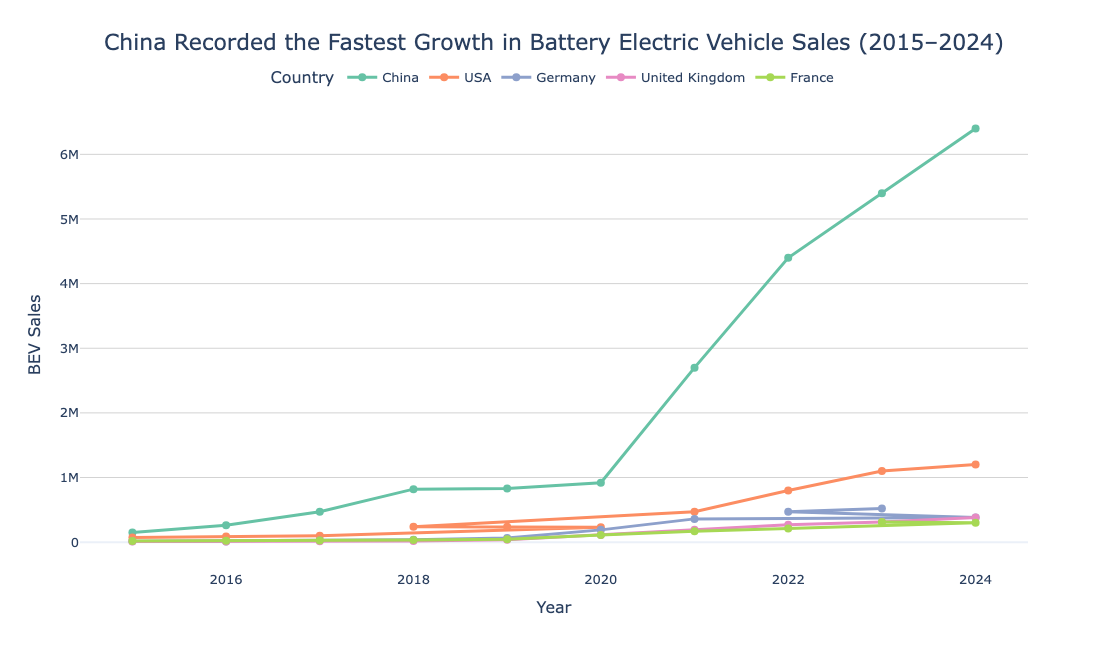

In [54]:
fig = px.line(
    country_sales_top5,
    x="year",
    y="value",
    color="region_country",
    markers=True,
    title="China Recorded the Fastest Growth in Battery Electric Vehicle Sales (2015–2024)",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_traces(
    line=dict(width=3),
    marker=dict(size=8)
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=650,
    title=dict(
        text="China Recorded the Fastest Growth in Battery Electric Vehicle Sales (2015–2024)",
        x=0.5,
        font=dict(size=22)
    ),
    font=dict(size=13),
    xaxis_title="Year",
    yaxis_title="BEV Sales",
    legend=dict(
        title="Country",
        orientation="h",
        y=1.08,
        x=0.5,
        xanchor="center"
    ),
    hovermode="x unified"
)

fig.update_xaxes(showgrid=False)

fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgrey",
    tickformat=",.0s"
)

fig.show()

### Insight

- China experienced the fastest growth in Battery Electric Vehicle (BEV) sales between 2015 and 2024.
- After 2020, China's BEV sales accelerated rapidly, creating a substantial lead over all other major markets.
- The United States, Germany, the United Kingdom, and France also recorded steady growth, but their sales remained considerably lower than China's.
- The results highlight China's dominant role in driving the global transition towards battery electric mobility.

# 7. Analytical Question 3

## Question

**How has the global electric vehicle stock evolved over time, and how has the contribution of Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) changed?**

### Why this question?

Vehicle sales represent annual market activity, whereas EV stock reflects the cumulative adoption of electric vehicles. Comparing BEVs and PHEVs over time provides insights into the long-term transition toward fully electric mobility.

In [56]:
stock_world = (
    ev_analysis[
        (ev_analysis["parameter"] == "EV stock") &
        (ev_analysis["region_country"] == "World")
    ]
    .groupby(["year", "powertrain"], as_index=False)["value"]
    .sum()
)

stock_world.head()

,year,powertrain,value
0,2010,BEV,20000.0
1,2010,PHEV,400.0
2,2011,BEV,58000.0
3,2011,PHEV,9500.0
4,2012,BEV,120000.0


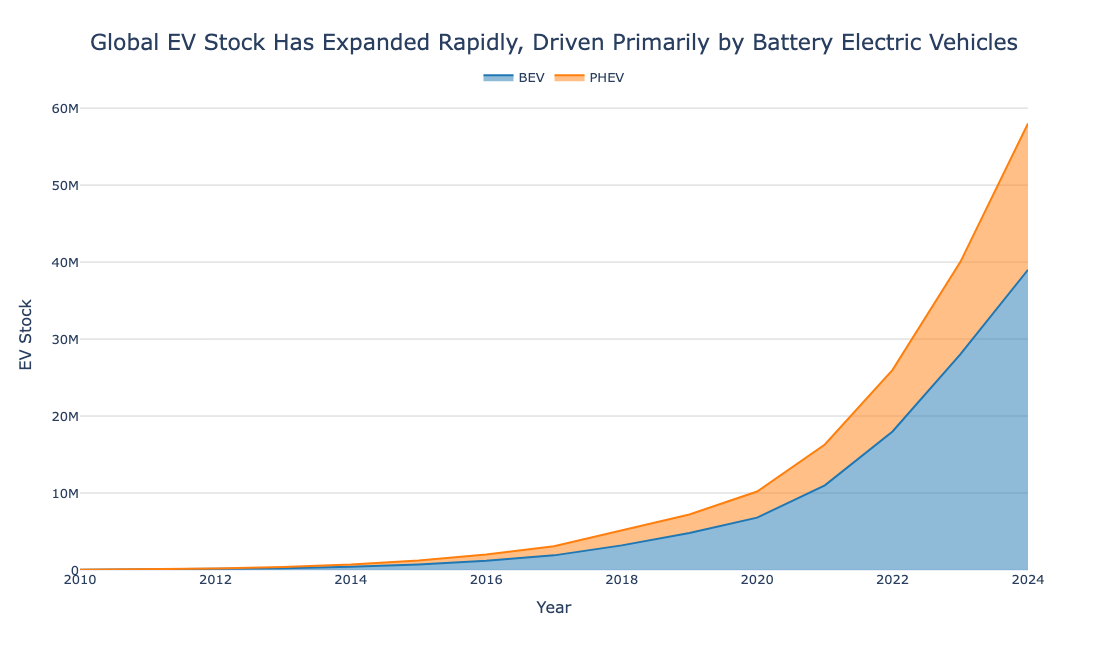

In [57]:
fig = px.area(
    stock_world,
    x="year",
    y="value",
    color="powertrain",
    title="Global EV Stock Has Expanded Rapidly, Driven Primarily by Battery Electric Vehicles",
    color_discrete_map={
        "BEV": "#1f77b4",
        "PHEV": "#ff7f0e"
    }
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=650,
    title=dict(
        text="Global EV Stock Has Expanded Rapidly, Driven Primarily by Battery Electric Vehicles",
        x=0.5,
        font=dict(size=22)
    ),
    font=dict(size=13),
    xaxis_title="Year",
    yaxis_title="EV Stock",
    hovermode="x unified",
    legend=dict(
        orientation="h",
        y=1.08,
        x=0.5,
        xanchor="center",
        title=""
    )
)

fig.update_yaxes(
    tickformat=",.0s",
    showgrid=True,
    gridcolor="lightgrey"
)

fig.update_xaxes(showgrid=False)

fig.show()

### Insight

- Global EV stock has increased substantially over the past decade.
- Battery Electric Vehicles (BEVs) account for the majority of cumulative EV stock.
- The gap between BEVs and PHEVs has widened considerably since 2020.
- The results indicate that fully electric vehicles are becoming the dominant technology in the global vehicle fleet.

# 8. Analytical Question 4

## Question

**Which countries accounted for the highest Battery Electric Vehicle (BEV) sales in 2024?**

### Why this question?

Comparing BEV sales across countries for the most recent year provides a snapshot of the current global market and identifies the leading contributors to electric vehicle adoption. This comparison highlights market concentration and reveals which countries are driving the transition toward battery electric mobility.

---

In [59]:
sales_2024 = ev_analysis[
    (ev_analysis["parameter"] == "EV sales") &
    (ev_analysis["powertrain"] == "BEV") &
    (ev_analysis["year"] == 2024)
].copy()

In [60]:
exclude = [
    "World",
    "Europe",
    "EU27",
    "Asia Pacific",
    "North America",
    "Central and South America",
    "Rest of the world",
    "Other"
]

sales_2024 = sales_2024[
    ~sales_2024["region_country"].isin(exclude)
]

In [61]:
top10_2024 = (
    sales_2024
    .sort_values("value", ascending=False)
    .head(10)
)

top10_2024

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
24,China,Historical,EV sales,Cars,BEV,2024,Vehicles,6400000.0,Other
104,USA,Historical,EV sales,Cars,BEV,2024,Vehicles,1200000.0,Other
217,Germany,Historical,EV sales,Cars,BEV,2024,Vehicles,380000.0,Other
218,United Kingdom,Historical,EV sales,Cars,BEV,2024,Vehicles,380000.0,Other
247,France,Historical,EV sales,Cars,BEV,2024,Vehicles,300000.0,Other
323,Canada,Historical,EV sales,Cars,BEV,2024,Vehicles,190000.0,Other
398,Belgium,Historical,EV sales,Cars,BEV,2024,Vehicles,130000.0,Other
406,Netherlands,Historical,EV sales,Cars,BEV,2024,Vehicles,130000.0,Other
426,Korea,Historical,EV sales,Cars,BEV,2024,Vehicles,120000.0,Other
447,Norway,Historical,EV sales,Cars,BEV,2024,Vehicles,110000.0,Other


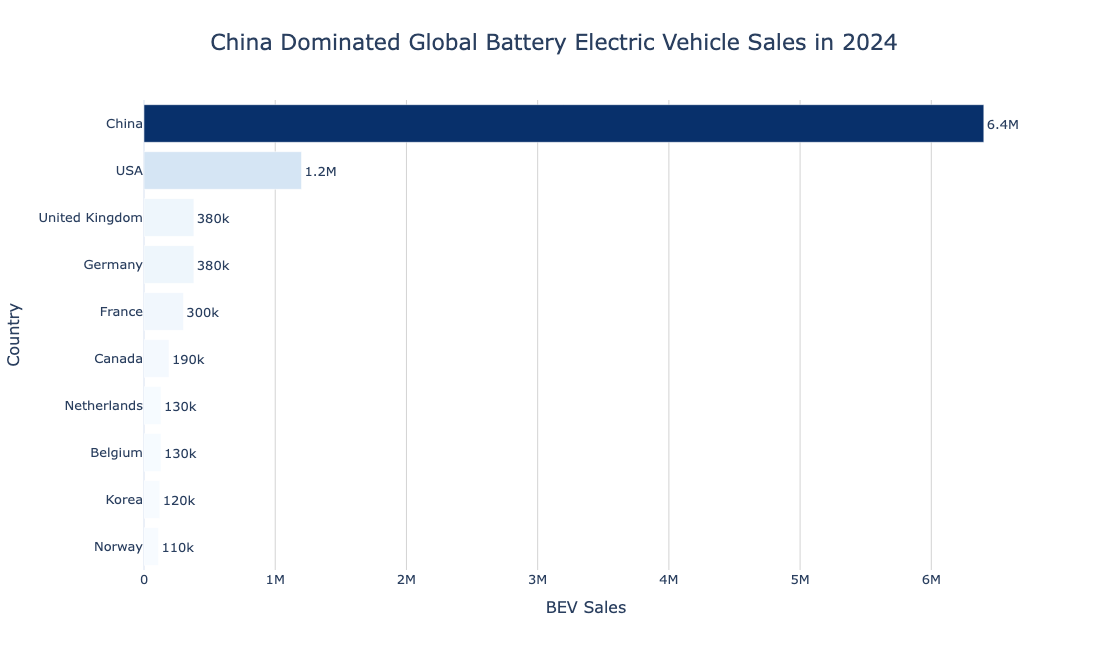

In [62]:
fig = px.bar(
    top10_2024,
    x="value",
    y="region_country",
    orientation="h",
    text="value",
    color="value",
    color_continuous_scale="Blues",
    title="China Dominated Global Battery Electric Vehicle Sales in 2024"
)

fig.update_traces(
    texttemplate="%{text:.2s}",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=650,
    title=dict(
        text="China Dominated Global Battery Electric Vehicle Sales in 2024",
        x=0.5,
        font=dict(size=22)
    ),
    font=dict(size=13),
    xaxis_title="BEV Sales",
    yaxis_title="Country",
    coloraxis_showscale=False
)

fig.update_xaxes(
    tickformat=",.0s",
    showgrid=True,
    gridcolor="lightgrey"
)

fig.update_yaxes(categoryorder="total ascending")

fig.show()

### Insight

- China recorded the highest Battery Electric Vehicle (BEV) sales in 2024, substantially outperforming every other country.
- The United States ranked second, followed by Germany and the United Kingdom.
- The large gap between China and the remaining countries demonstrates China's dominant position in the global BEV market.
- The results indicate that BEV adoption is highly concentrated in a small number of leading markets.

# 9. Analytical Question 5

## Question

**How does Battery Electric Vehicle (BEV) sales distribution vary across countries in 2024?**

### Why this question?

Geographical patterns play a significant role in understanding electric vehicle adoption. Visualising BEV sales on a world map highlights regional differences, identifies leading markets, and reveals the global distribution of electric vehicle adoption.

---

In [63]:
map_data = ev_analysis[
    (ev_analysis["parameter"] == "EV sales") &
    (ev_analysis["powertrain"] == "BEV") &
    (ev_analysis["year"] == 2024)
].copy()

exclude = [
    "World",
    "Europe",
    "EU27",
    "Asia Pacific",
    "North America",
    "Central and South America",
    "Rest of the world",
    "Other"
]

map_data = map_data[
    ~map_data["region_country"].isin(exclude)
]

/var/folders/41/vny736b909l2ld5tm2h469rr0000gn/T/ipykernel_63174/2316131867.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


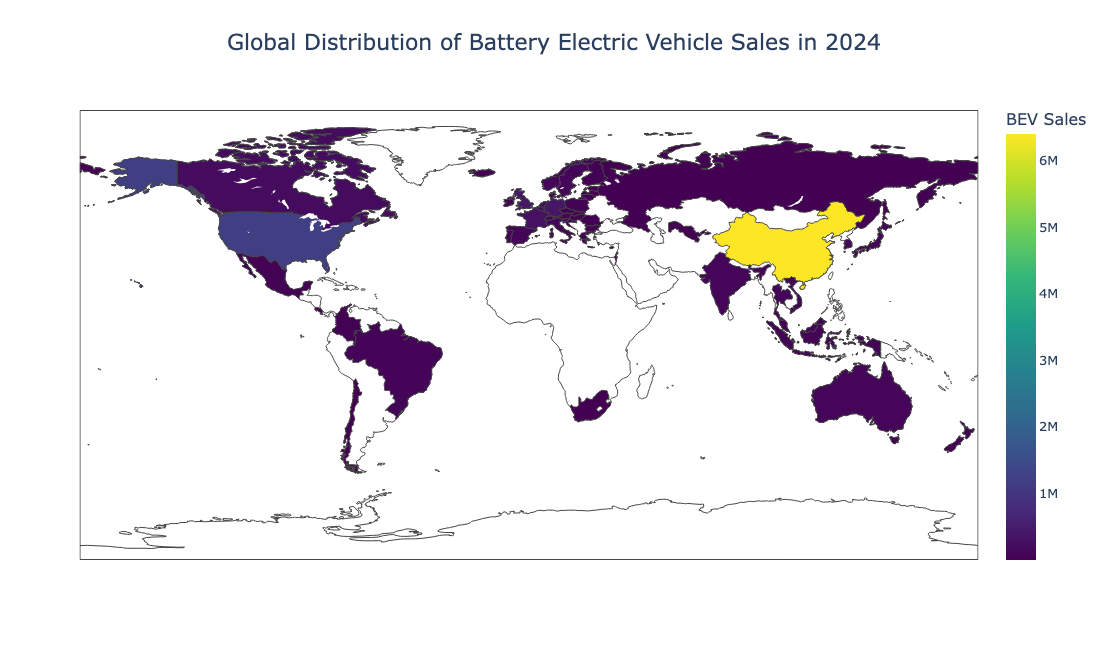

In [64]:
fig = px.choropleth(
    map_data,
    locations="region_country",
    locationmode="country names",
    color="value",
    hover_name="region_country",
    color_continuous_scale="Viridis",
    title="Global Distribution of Battery Electric Vehicle Sales in 2024"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=650,
    title=dict(
        text="Global Distribution of Battery Electric Vehicle Sales in 2024",
        x=0.5,
        font=dict(size=22)
    ),
    font=dict(size=13),
    coloraxis_colorbar_title="BEV Sales"
)

fig.show()

### Insight

- BEV sales are highly concentrated in a small number of countries.
- China dominates global BEV sales, while the United States and several European countries also demonstrate strong adoption.
- Large parts of South America, Africa, and other developing regions show comparatively lower BEV sales.
- The geographical distribution highlights unequal levels of electric vehicle adoption across the world.

# 10. Analytical Question 6

## Question

**How is the global Battery Electric Vehicle (BEV) market distributed across major regions and countries in 2024?**

### Why this question?

Understanding how BEV sales are distributed across regions and countries helps identify market concentration and reveals which geographic areas are driving global electric vehicle adoption.

---

In [65]:
treemap_data = ev_analysis[
    (ev_analysis["parameter"] == "EV sales") &
    (ev_analysis["powertrain"] == "BEV") &
    (ev_analysis["year"] == 2024)
].copy()

exclude = [
    "World",
    "Europe",
    "EU27",
    "North America",
    "Central and South America",
    "Asia Pacific",
    "Rest of the world",
    "Other"
]

treemap_data = treemap_data[
    ~treemap_data["region_country"].isin(exclude)
]

In [66]:
europe = [
    "Germany","France","United Kingdom","Norway","Netherlands",
    "Sweden","Italy","Spain","Austria","Belgium","Denmark",
    "Finland","Switzerland","Portugal","Poland","Ireland",
    "Czech Republic","Slovakia","Hungary","Luxembourg","Iceland"
]

asia = [
    "China","Japan","Korea","India","Indonesia","Thailand",
    "Malaysia","Singapore","Viet Nam","Chinese Taipei","Israel","Türkiye"
]

north_america = [
    "USA","Canada","Mexico"
]

oceania = [
    "Australia","New Zealand"
]

def region(country):
    if country in europe:
        return "Europe"
    elif country in asia:
        return "Asia"
    elif country in north_america:
        return "North America"
    elif country in oceania:
        return "Oceania"
    else:
        return "Other"

treemap_data["Region"] = treemap_data["region_country"].apply(region)

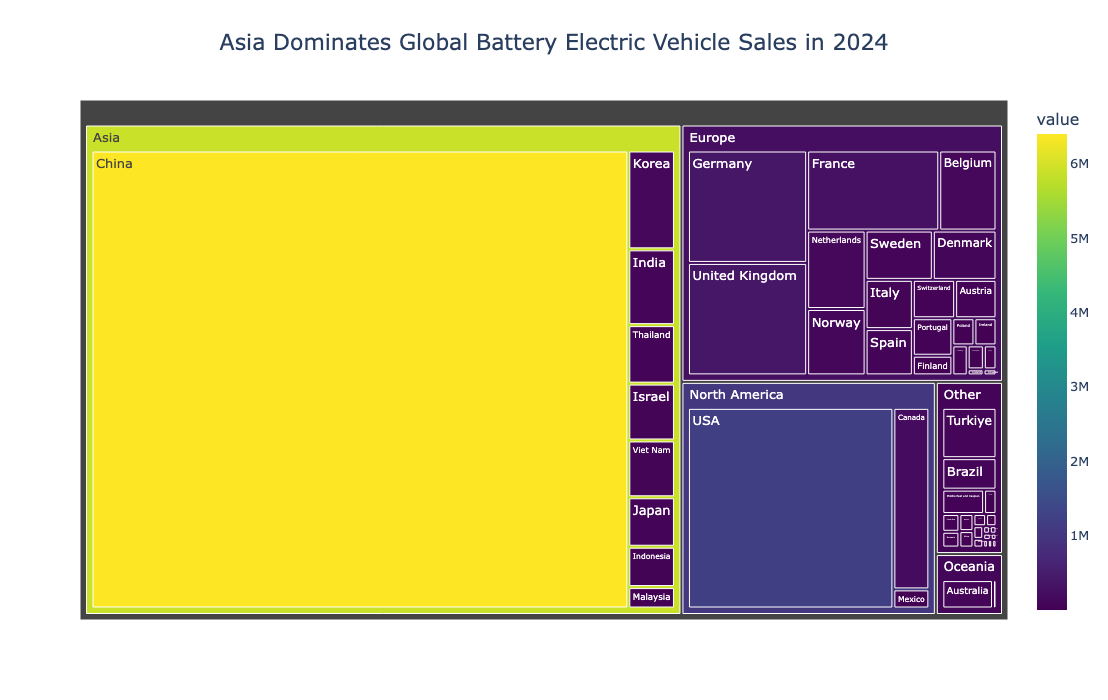

In [67]:
fig = px.treemap(
    treemap_data,
    path=["Region", "region_country"],
    values="value",
    color="value",
    color_continuous_scale="Viridis",
    title="Asia Dominates Global Battery Electric Vehicle Sales in 2024"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=700,
    title=dict(
        text="Asia Dominates Global Battery Electric Vehicle Sales in 2024",
        x=0.5,
        font=dict(size=22)
    ),
    font=dict(size=13)
)

fig.show()

### Insight

- Asia represents the largest share of global Battery Electric Vehicle (BEV) sales, primarily driven by China.
- Europe contributes through several strong markets, including Germany, France, and the United Kingdom.
- North America is dominated by the United States, while Canada contributes a comparatively smaller share.
- The treemap highlights that global BEV sales are concentrated in a limited number of countries, with China accounting for the largest proportion.

# 11. Analytical Question 7

## Question

**How have Battery Electric Vehicle (BEV) sales evolved across the world's leading markets between 2015 and 2024?**

### Why this question?

Comparing BEV sales across countries and years helps identify periods of rapid growth, market acceleration, and differences in adoption patterns among leading EV markets.

---

In [68]:
heatmap_data = ev_analysis[
    (ev_analysis["parameter"] == "EV sales") &
    (ev_analysis["powertrain"] == "BEV") &
    (ev_analysis["year"] >= 2015)
].copy()

exclude = [
    "World",
    "Europe",
    "EU27",
    "Asia Pacific",
    "North America",
    "Central and South America",
    "Rest of the world",
    "Other"
]

heatmap_data = heatmap_data[
    ~heatmap_data["region_country"].isin(exclude)
]

In [69]:
top10 = (
    heatmap_data.groupby("region_country")["value"]
    .sum()
    .nlargest(10)
    .index
)

heatmap_data = heatmap_data[
    heatmap_data["region_country"].isin(top10)
]

In [70]:
heatmap = heatmap_data.pivot_table(
    index="region_country",
    columns="year",
    values="value",
    aggfunc="sum"
)

heatmap

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
region_country,,,,,,,,,,
Canada,4400.0,5200.0,8700.0,23000.0,32000.0,37000.0,59000.0,91000.0,130000.0,190000.0
China,150000.0,260000.0,470000.0,820000.0,830000.0,920000.0,2700000.0,4400000.0,5400000.0,6400000.0
France,18000.0,23000.0,26000.0,33000.0,45000.0,110000.0,170000.0,210000.0,310000.0,300000.0
Germany,12000.0,11000.0,25000.0,36000.0,63000.0,190000.0,360000.0,470000.0,520000.0,380000.0
Korea,3100.0,4700.0,14000.0,55000.0,33000.0,31000.0,72000.0,120000.0,120000.0,120000.0
Netherlands,3400.0,4000.0,8000.0,24000.0,61000.0,72000.0,63000.0,73000.0,110000.0,130000.0
Norway,26000.0,24000.0,33000.0,46000.0,60000.0,77000.0,110000.0,140000.0,100000.0,110000.0
Sweden,3000.0,2900.0,4400.0,7100.0,16000.0,28000.0,57000.0,96000.0,110000.0,94000.0
USA,71000.0,87000.0,100000.0,240000.0,240000.0,230000.0,470000.0,800000.0,1100000.0,1200000.0


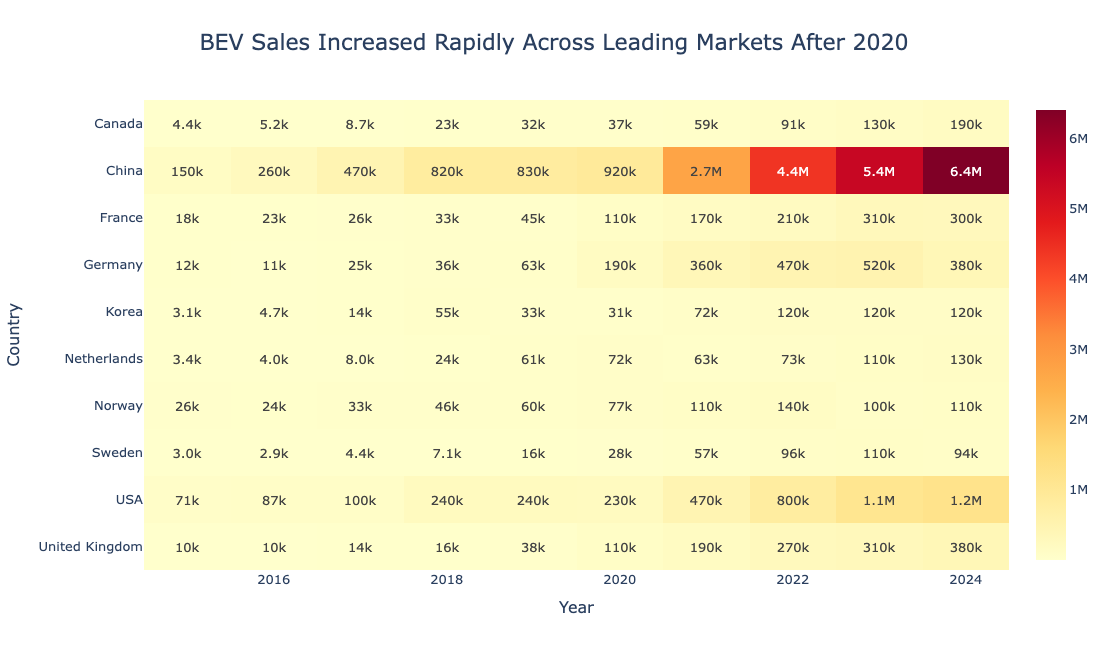

In [71]:
fig = px.imshow(
    heatmap,
    text_auto=".2s",
    color_continuous_scale="YlOrRd",
    aspect="auto",
    title="BEV Sales Increased Rapidly Across Leading Markets After 2020"
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=650,
    title=dict(
        text="BEV Sales Increased Rapidly Across Leading Markets After 2020",
        x=0.5,
        font=dict(size=22)
    ),
    xaxis_title="Year",
    yaxis_title="Country",
    font=dict(size=13)
)

fig.show()

### Insight

- BEV sales increased substantially across all leading markets after 2020.
- China shows the highest sales volumes throughout the later years, indicating exceptional market expansion.
- The United States and Germany also experienced strong growth, although at a lower scale.
- The heatmap clearly highlights the acceleration of global BEV adoption during the past five years.

# 12. Analytical Question 8

## Question

**What is the relationship between Battery Electric Vehicle (BEV) sales and EV stock across leading countries in 2024?**

### Why this question?

Comparing annual BEV sales with cumulative EV stock helps determine whether countries with large existing EV fleets also continue to achieve strong annual sales. This analysis reveals the relationship between market maturity and ongoing adoption.

---

In [72]:
sales = ev_analysis[
    (ev_analysis["parameter"] == "EV sales") &
    (ev_analysis["powertrain"] == "BEV") &
    (ev_analysis["year"] == 2024)
][["region_country", "value"]].rename(columns={"value": "Sales"})

stock = ev_analysis[
    (ev_analysis["parameter"] == "EV stock") &
    (ev_analysis["powertrain"] == "BEV") &
    (ev_analysis["year"] == 2024)
][["region_country", "value"]].rename(columns={"value": "Stock"})

In [73]:
bubble = sales.merge(stock, on="region_country")

exclude = [
    "World",
    "Europe",
    "EU27",
    "Asia Pacific",
    "North America",
    "Central and South America",
    "Rest of the world",
    "Other"
]

bubble = bubble[
    ~bubble["region_country"].isin(exclude)
]

bubble.head()

,region_country,Sales,Stock
2,China,6400000.0,23000000.0
6,USA,1200000.0,4700000.0
7,Germany,380000.0,1900000.0
8,United Kingdom,380000.0,1400000.0
9,France,300000.0,1100000.0


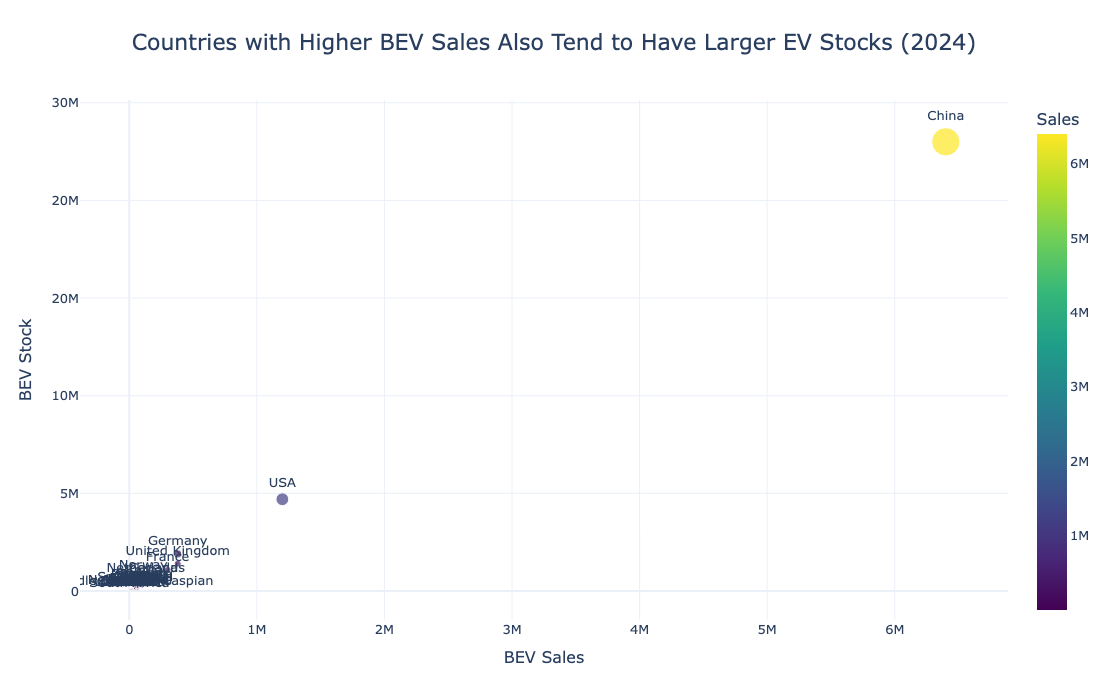

In [74]:
fig = px.scatter(
    bubble,
    x="Sales",
    y="Stock",
    size="Stock",
    color="Sales",
    hover_name="region_country",
    text="region_country",
    color_continuous_scale="Viridis",
    title="Countries with Higher BEV Sales Also Tend to Have Larger EV Stocks (2024)"
)

fig.update_traces(textposition="top center")

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=700,
    title=dict(
        text="Countries with Higher BEV Sales Also Tend to Have Larger EV Stocks (2024)",
        x=0.5,
        font=dict(size=22)
    ),
    xaxis_title="BEV Sales",
    yaxis_title="BEV Stock",
    font=dict(size=13)
)

fig.update_xaxes(tickformat=",.0s")
fig.update_yaxes(tickformat=",.0s")

fig.show()

### Insight

- Countries with higher annual BEV sales generally also maintain larger cumulative EV stocks.
- China stands out as the dominant market, recording both the highest annual sales and the largest EV fleet.
- The positive relationship between sales and stock suggests that mature EV markets continue to experience sustained growth.
- Smaller markets remain clustered in the lower-left corner, reflecting both lower annual sales and smaller cumulative EV fleets.

# 13. Analytical Question 9

## Question

**How are global electric vehicle sales distributed across powertrains and leading countries in 2024?**

### Why this question?

Understanding how BEV and PHEV sales c
ontribute within each country provides insights into market composition and technology preferences. This hierarchical comparison reveals whether countries are primarily adopting fully electric vehicles or plug-in hybrids.

---

In [75]:
sunburst_data = ev_analysis[
    (ev_analysis["parameter"] == "EV sales") &
    (ev_analysis["year"] == 2024)
].copy()

exclude = [
    "World",
    "Europe",
    "EU27",
    "North America",
    "Central and South America",
    "Asia Pacific",
    "Rest of the world",
    "Other"
]

sunburst_data = sunburst_data[
    ~sunburst_data["region_country"].isin(exclude)
]

top10 = (
    sunburst_data.groupby("region_country")["value"]
    .sum()
    .nlargest(10)
    .index
)

sunburst_data = sunburst_data[
    sunburst_data["region_country"].isin(top10)
]

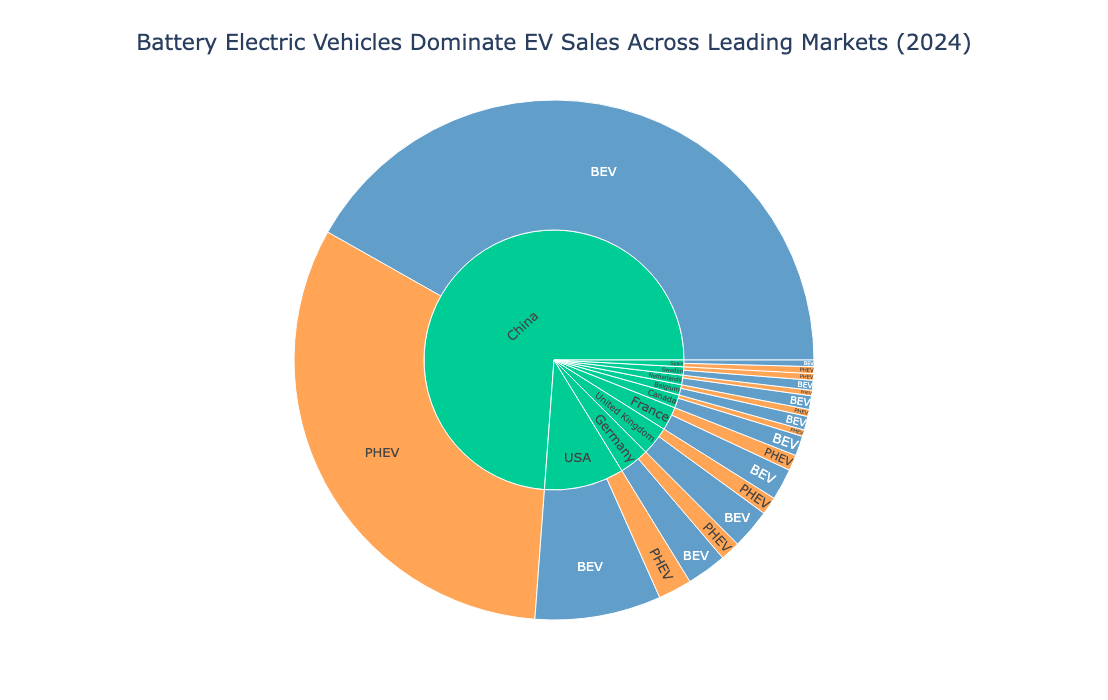

In [76]:
fig = px.sunburst(
    sunburst_data,
    path=["region_country", "powertrain"],
    values="value",
    color="powertrain",
    color_discrete_map={
        "BEV": "#1f77b4",
        "PHEV": "#ff7f0e"
    },
    title="Battery Electric Vehicles Dominate EV Sales Across Leading Markets (2024)"
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=700,
    title=dict(
        text="Battery Electric Vehicles Dominate EV Sales Across Leading Markets (2024)",
        x=0.5,
        font=dict(size=22)
    ),
    font=dict(size=13)
)

fig.show()

### Insight

- Battery Electric Vehicles (BEVs) account for the largest share of EV sales in most leading markets.
- China contributes the largest share of global EV sales, with BEVs representing the dominant powertrain.
- While PHEVs remain relevant in several countries, BEVs are the preferred technology across the majority of top EV markets.

# 14. Analytical Question 10

## Question

**How has Battery Electric Vehicle (BEV) adoption evolved across leading countries between 2015 and 2024?**

### Why this question?

Tracking BEV sales over time using an animated visualization highlights how different countries have progressed through various stages of electric vehicle adoption and identifies emerging leaders over the past decade.

---

In [77]:
animation_data = ev_analysis[
    (ev_analysis["parameter"] == "EV sales") &
    (ev_analysis["powertrain"] == "BEV") &
    (ev_analysis["year"] >= 2015)
].copy()

exclude = [
    "World",
    "Europe",
    "EU27",
    "North America",
    "Central and South America",
    "Asia Pacific",
    "Rest of the world",
    "Other"
]

animation_data = animation_data[
    ~animation_data["region_country"].isin(exclude)
]

top10 = (
    animation_data.groupby("region_country")["value"]
    .sum()
    .nlargest(10)
    .index
)

animation_data = animation_data[
    animation_data["region_country"].isin(top10)
]

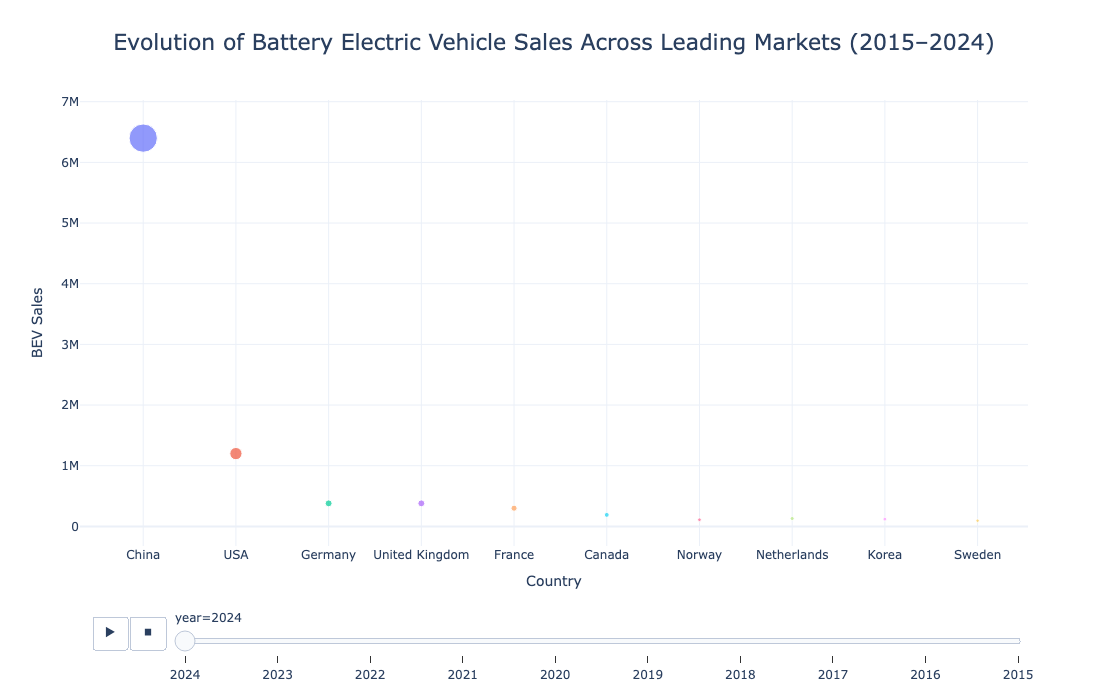

In [78]:
fig = px.scatter(
    animation_data,
    x="region_country",
    y="value",
    size="value",
    color="region_country",
    animation_frame="year",
    animation_group="region_country",
    hover_name="region_country",
    title="Evolution of Battery Electric Vehicle Sales Across Leading Markets (2015–2024)"
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=700,
    title=dict(
        text="Evolution of Battery Electric Vehicle Sales Across Leading Markets (2015–2024)",
        x=0.5,
        font=dict(size=22)
    ),
    xaxis_title="Country",
    yaxis_title="BEV Sales",
    showlegend=False
)

fig.update_yaxes(tickformat=",.0s")

fig.show()

### Insight

- The animation illustrates the rapid acceleration of BEV sales after 2020 across major markets.
- China consistently maintains the highest sales throughout the period, widening its lead in later years.
- Other countries, including the United States and Germany, demonstrate steady growth but remain well below China's sales levels.
- The animation clearly highlights the global shift towards battery electric mobility over the past decade.

# 15. Conclusion

This project explored global electric vehicle adoption using the IEA Global EV Outlook 2025 dataset through ten analytical questions and interactive Plotly visualizations.

The analysis revealed several key findings:

- Global electric vehicle adoption has accelerated significantly since 2020.
- Battery Electric Vehicles (BEVs) consistently outperform Plug-in Hybrid Electric Vehicles (PHEVs) in both annual sales and cumulative vehicle stock.
- China has emerged as the dominant global EV market, leading in both annual sales and cumulative EV stock.
- The United States, Germany, and several European countries also demonstrated strong growth, although at considerably lower levels than China.
- Geographic and regional visualizations highlighted that EV adoption remains concentrated in a relatively small number of leading markets.

Overall, the combination of multiple visualization techniques—including line charts, area charts, bar charts, treemaps, choropleth maps, heatmaps, and scatter plots—provided complementary insights into global EV adoption patterns, market composition, and regional differences. These findings demonstrate the value of interactive data visualization for exploring complex trends and communicating analytical insights effectively.